In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
mimic_A = pd.read_parquet("fit_data_Z.parquet")

In [7]:
mimic_A

,admission_id,t0,tD,tsd,Z,A,vent_mode__last__last_12h,cumavg_vent_mode__hours_since_last__last_12h,cumavg_pco2_arterial__mean__last_12h,cumavg_po2_arterial__mean__last_12h,...,cumavg_lactate__last__last_12h,cumavg_fluid_out_urine__mean__last_12h,cumavg_ureum__last__last_12h,cumavg_creatinine__last__last_12h,cumavg_arterial_blood_pressure_mean__mean__last_12h,cumavg_heart_rate__mean__last_12h,cumavg_hemoglobin__last__last_12h,cumavg_temperature__mean__last_12h,cumavg_activated_partial_thromboplastin_time__last__last_12h,cumavg_bicarbonate_arterial__last__last_12h
0,mimic4-30000153,1,1,0,0,1,unknown,6.983333,44.000000,233.0,...,1.6,68.611111,14.280000,141.440002,88.113556,106.746792,10.5,37.479166,44.099998,20.0
1,mimic4-30000153,2,1,1,0,1,unknown,6.983333,44.000000,233.0,...,1.6,68.611111,14.280000,141.440002,88.113556,106.746792,10.5,37.479166,44.099998,20.0
2,mimic4-30000153,3,1,2,0,1,unknown,6.983333,44.000000,233.0,...,1.6,68.611111,14.280000,141.440002,88.113556,106.746792,10.5,37.479166,44.099998,20.0
3,mimic4-30000153,4,1,3,0,1,unknown,6.983333,44.000000,233.0,...,1.6,68.611111,14.280000,141.440002,88.113556,106.746792,10.5,37.479166,44.099998,20.0
4,mimic4-30000153,5,1,4,0,1,unknown,6.983333,44.000000,233.0,...,1.6,68.611111,14.280000,141.440002,88.113556,106.746792,10.5,37.479166,44.099998,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12099728,mimic4-39997955,175,8,167,0,1,unknown,3.811667,43.599998,180.0,...,3.4,207.388568,26.060999,150.280014,93.509260,77.495728,7.0,36.784982,32.599998,21.0
12099729,mimic4-39997955,176,8,168,0,1,unknown,3.811667,43.599998,180.0,...,3.4,207.388568,26.060999,150.280014,93.509260,77.495728,7.0,36.784982,32.599998,21.0
12099730,mimic4-39997955,177,8,169,0,1,unknown,3.811667,43.599998,180.0,...,3.4,207.388568,26.060999,150.280014,93.509260,77.495728,7.0,36.784982,32.599998,21.0
12099731,mimic4-39997955,178,8,170,0,1,unknown,3.811667,43.599998,180.0,...,3.4,207.388568,26.060999,150.280014,93.509260,77.495728,7.0,36.784982,32.599998,21.0


In [9]:
mimic_A.admission_id.nunique()

76379

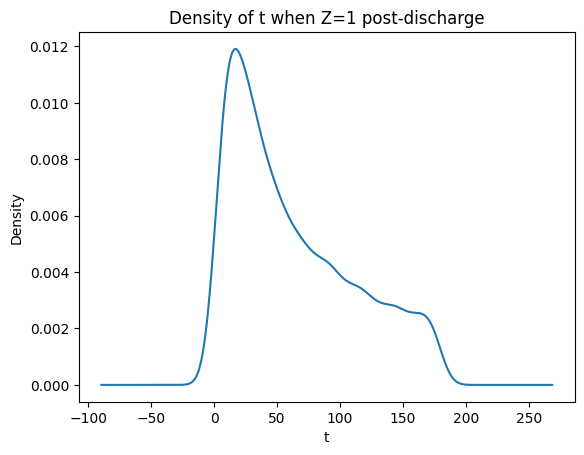

Number of admissions contributing: 10554


In [19]:
# --- Step 1: Filter rows where A=1 and Z=1 ---

DS = mimic_A.copy()

df_filtered = DS[(DS['A'] == 1) & (DS['Z'] == 1)].copy()

# --- Step 2: For each admission_id, pick the first t0 ---
t0_per_adm = (
    df_filtered
    .sort_values(['admission_id', 't0'])
    .groupby('admission_id')['t0']
    .first()
)

# Drop missing if any
#t0_per_adm = t0_per_adm.dropna()

# --- Step 3: Plot density ---
plt.figure()
t0_per_adm.plot(kind='density')

plt.xlabel('t')
plt.ylabel('Density')
plt.title('Density of t when Z=1 post-discharge')
plt.show()

print("Number of admissions contributing:", len(t0_per_adm))
#plt.savefig("t_density_after_discharge.png")
#plt.close()


In [10]:
t0_per_adm

admission_id
mimic4-30000484     74
mimic4-30000646     13
mimic4-30004391    140
mimic4-30007228     18
mimic4-30011071     54
                  ... 
mimic4-39993265     14
mimic4-39993425      5
mimic4-39995141     22
mimic4-39995630     84
mimic4-39996044    150
Name: t0, Length: 10554, dtype: int64

In [12]:
df_filtered.t0.min()

np.int64(0)

<Axes: >

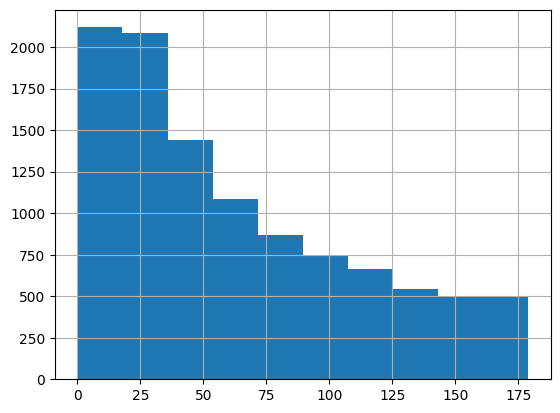

In [21]:
t0_per_adm.hist()

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Step 1: Filter rows where A=1 and Z=1 ---
df_filtered = DS[(DS['A'] == 1) & (DS['Z'] == 1)].copy()

# --- Step 2: First t0 per admission_id ---
t0_per_adm = (
    df_filtered
    .sort_values(['admission_id', 't0'])
    .groupby('admission_id')['t0']
    .first()
    .dropna()
)

print("Number of admissions contributing:", len(t0_per_adm))

# =========================
# Density Plot
# =========================
plt.figure()
t0_per_adm.plot(kind='density')

plt.xlabel('t')
plt.ylabel('Density')
plt.title('Density of t when Z=1 post-discharge')

plt.savefig("density_t_A1_Z1.png", dpi=300, bbox_inches='tight')
plt.close()

# =========================
# Histogram Plot
# =========================
plt.figure()
plt.hist(t0_per_adm, bins=30, density=True)

plt.xlabel('t')
plt.ylabel('Number')
plt.title('Histogram of t when Z=1 post-discharge')

plt.savefig("histogram_t_A1_Z1.png", dpi=300, bbox_inches='tight')
plt.close()

print("Saved:")
print(" - density_t0_A1_Z1.png")
print(" - histogram_t0_A1_Z1.png")


Number of admissions contributing: 10554
Saved:
 - density_t0_A1_Z1.png
 - histogram_t0_A1_Z1.png
